In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv('./data_banknote_authentication.csv')

In [33]:
df.head()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


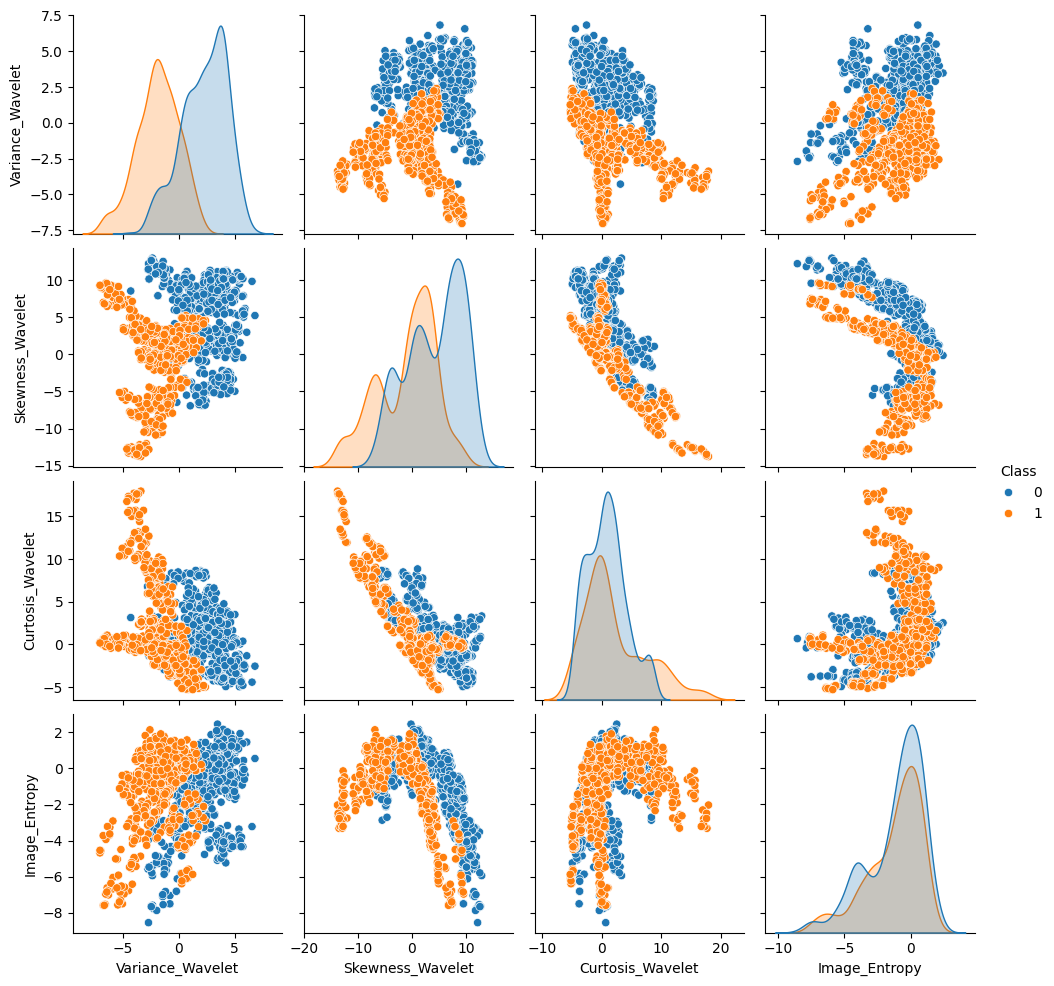

In [34]:
sns.pairplot(df, hue='Class')

In [35]:
X = df.drop('Class', axis=1)

In [36]:
y = df['Class']

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=101)

In [39]:
from sklearn.model_selection import GridSearchCV

In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
help(RandomForestClassifier)

Help on class RandomForestClassifier in module sklearn.ensemble._forest:

class RandomForestClassifier(ForestClassifier)
 |  RandomForestClassifier(
 |      n_estimators=100,
 |      *,
 |      criterion='gini',
 |      max_depth=None,
 |      min_samples_split=2,
 |      min_samples_leaf=1,
 |      min_weight_fraction_leaf=0.0,
 |      max_features='sqrt',
 |      max_leaf_nodes=None,
 |      min_impurity_decrease=0.0,
 |      bootstrap=True,
 |      oob_score=False,
 |      n_jobs=None,
 |      random_state=None,
 |      verbose=0,
 |      warm_start=False,
 |      class_weight=None,
 |      ccp_alpha=0.0,
 |      max_samples=None,
 |      monotonic_cst=None
 |  )
 |
 |  A random forest classifier.
 |
 |  A random forest is a meta estimator that fits a number of decision tree
 |  classifiers on various sub-samples of the dataset and uses averaging to
 |  improve the predictive accuracy and control over-fitting.
 |  Trees in the forest use the best split strategy, i.e. equivalent to p

    Hyper parameters we need to check, so we will pass them and clerify them accordingly.

In [42]:
n_estimators = [64, 100, 128, 200]

In [43]:
max_features = [2,3,4]

In [44]:
bootstrap = [True, False]

In [45]:
oob_score = [True, False] # out of bag score, it is a measure of generalization

In [46]:
param_grid = {'n_estimators': n_estimators, 'max_features': max_features, 'bootstrap': bootstrap, 'oob_score': oob_score}

In [47]:
rfc = RandomForestClassifier()

In [48]:
grid = GridSearchCV(estimator=rfc, param_grid=param_grid) #Exhaustive search over specified parameter values for an estimator.



In [49]:
grid.fit(X_train, y_train)

d:\Programs\Github\data-science-concepts\myenv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
60 fits failed out of a total of 240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Programs\Github\data-science-concepts\myenv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Programs\Github\data-science-concepts\myenv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "d:\Programs\Github\data-science-concepts\mye

,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True, False], 'max_features': [2, 3, ...], 'n_estimators': [64, 100, ...], 'oob_score': [True, False]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,64


In [50]:
grid.best_params_

{'bootstrap': True, 'max_features': 2, 'n_estimators': 64, 'oob_score': True}

In [51]:
rfc = RandomForestClassifier(bootstrap=True, max_features=2, n_estimators=100, oob_score=False)
rfc.fit(X_train, y_train) #recreating the model 

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
predictions = rfc.predict(X_test)

In [54]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [55]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       124
           1       0.98      1.00      0.99        82

    accuracy                           0.99       206
   macro avg       0.99      0.99      0.99       206
weighted avg       0.99      0.99      0.99       206



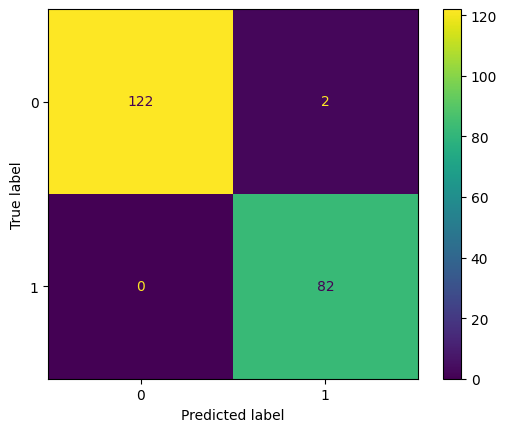

In [56]:
ConfusionMatrixDisplay(confusion_matrix(y_test, predictions)).plot()

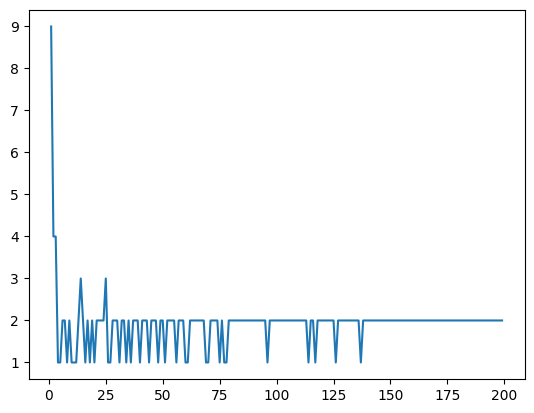

In [58]:
errors = []
misclassifications = []

for n in range(1,200):
    rfc = RandomForestClassifier(bootstrap=True, max_features=2, n_estimators=n, oob_score=False)
    rfc.fit(X_train, y_train)
    predictions = rfc.predict(X_test)
    errors.append(n)
    misclassifications.append((y_test != predictions).sum())


#this will show the graph for the misclassifications as a function of the number of trees
plt.plot(errors, misclassifications)